# Feature Engineering - Dataset GMR-PL

Extraction des caractéristiques à partir des avis nettoyés pour la détection de faux avis.

## Importations et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ Toutes les importations réussies !")

✅ Toutes les importations réussies !


## Charger les Données Nettoyées

In [2]:
# Charger les données nettoyées
df = pd.read_csv('../data/processed/reviews_cleaned.csv')

print(f" DONNEES CHARGEES :")
print(f"  Shape : {df.shape}")
print(f"  Columns : {len(df.columns)}")

print(f"\n ECHANTILLON :")
display(df.head())

 DONNEES CHARGEES :
  Shape : (13351, 24)
  Columns : 24

 ECHANTILLON :


,review_id,account_id,approximate_localization.lat,approximate_localization.lon,censored_text,cluster,review_text,content_not_full,content_translated,date,...,rating,response_content,type_of_object,account_id_orig,is_deleted,is_private,is_real_account,local_guide_level,name_score,number_of_reviews
0,63e2e0d98b0803f03c00c02f,63e546a08f7e73edc5913876,53.3,15.9,False,Shops,Ok,False,False,2023-01-10T20:17:09.732Z,...,4,INCONNU,Dyskont spożywczy,63e546a08f7e73edc5913876,False,False,1,5.0,744861,78.0
1,63f2bcae8047cae56c427a1d,63e546a08f7e73edc5913876,53.6,15.6,False,Other services,Ok,False,False,2023-01-10T20:17:09.513Z,...,4,INCONNU,Magazyn,63e546a08f7e73edc5913876,False,False,1,5.0,744861,78.0
2,63f2bdf3ec2561ca0a25eb3d,63e546a08f7e73edc5913876,54.1,15.0,False,Lodging,Ok,False,False,2022-11-11T20:17:12.686Z,...,4,INCONNU,Hotel,63e546a08f7e73edc5913876,False,False,1,5.0,744861,78.0
3,63f2be19ec2561ca0a25eb4f,63e546a08f7e73edc5913876,53.5,15.8,False,Lodging,Jest super Więcej,True,False,2022-07-14T20:17:15.108Z,...,4,INCONNU,Hotel,63e546a08f7e73edc5913876,False,False,1,5.0,744861,78.0
4,63f2be1dec2561ca0a25eb51,63e546a08f7e73edc5913876,53.5,16.0,False,Shops,Ok,False,False,2022-07-14T20:17:15.313Z,...,4,INCONNU,Sklep dla majsterkowiczów,63e546a08f7e73edc5913876,False,False,1,5.0,744861,78.0


## FEATURE 1 : Statistiques du Texte

In [3]:
print("\n" + "=" * 80)
print("Feature 1 : STATISTIQUES DU TEXTE")
print("=" * 80)

# Statistiques de base
df['text_length'] = df['review_text'].astype(str).str.len()
df['word_count'] = df['review_text'].astype(str).str.split().str.len()
df['sentence_count'] = df['review_text'].astype(str).str.count(r'[.!?]+')

print(f"\n Caractéristiques créées :")
print(f"  • text_length")
print(f"  • word_count")
print(f"  • sentence_count")

# Afficher les statistiques
print(f"\n STATISTIQUES DU TEXTE :")
print(f"  Avg length : {df['text_length'].mean():.0f} chars")# chars->caractères
print(f"  Avg words : {df['word_count'].mean():.0f}")
print(f"  Avg sentences : {df['sentence_count'].mean():.2f}")


Feature 1 : STATISTIQUES DU TEXTE

 Caractéristiques créées :
  • text_length
  • word_count
  • sentence_count

 STATISTIQUES DU TEXTE :
  Avg length : 82 chars
  Avg words : 12
  Avg sentences : 1.16


## FEATURE 2 : Caractéristiques de Ponctuation

In [4]:
print("\n" + "=" * 80)
print("Feature 2 : CARACTERISTIQUES DE PONCTUATION")
print("=" * 80)

# Ponctuation
df['exclamation_count'] = df['review_text'].astype(str).str.count('!')
df['question_count'] = df['review_text'].astype(str).str.count('\?')

# Majuscules
df['caps_ratio'] = df['review_text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)) if len(str(x)) > 0 else 0
)

# Caractères spéciaux
df['special_char_count'] = df['review_text'].apply(
    lambda x: sum(1 for c in str(x) if not c.isalnum() and not c.isspace())
)

print(f"\n Caractéristiques créées :")
print(f"  • exclamation_count")
print(f"  • question_count")
print(f"  • caps_ratio")
print(f"  • special_char_count")

# Afficher les statistiques
print(f"\n STATISTIQUES DE PONCTUATION :")
print(f"  Moy. exclamations : {df['exclamation_count'].mean():.2f}")
print(f"  Moy. questions : {df['question_count'].mean():.2f}")
print(f"  Moy. ratio majuscules : {df['caps_ratio'].mean():.3f}")
print(f"  Moy. caractères spéciaux : {df['special_char_count'].mean():.1f}")


Feature 2 : CARACTERISTIQUES DE PONCTUATION

 Caractéristiques créées :
  • exclamation_count
  • question_count
  • caps_ratio
  • special_char_count

 STATISTIQUES DE PONCTUATION :
  Moy. exclamations : 0.15
  Moy. questions : 0.01
  Moy. ratio majuscules : 0.059
  Moy. caractères spéciaux : 3.0


## FEATURE 3 : Diversité Lexicale

In [5]:
print("\n" + "=" * 80)
print("Feature 3 : DIVERSITE LEXICALE")
print("=" * 80)

# Ratio de mots uniques
df['unique_words_ratio'] = df['review_text'].apply(
    lambda x: len(set(str(x).lower().split())) / len(str(x).split()) if len(str(x).split()) > 0 else 0
)

# Longueur moyenne des mots
df['avg_word_length'] = df['review_text'].apply(
    lambda x: np.mean([len(word) for word in str(x).split()]) if len(str(x).split()) > 0 else 0
)

print(f"\n Caractéristiques créées :")
print(f"  • unique_words_ratio")
print(f"  • avg_word_length")

print(f"\n STATISTIQUES LEXICALES :")
print(f"  Avg unique ratio : {df['unique_words_ratio'].mean():.3f}") # ratio = nombre de mots uniques / nombre total de mots
print(f"  Avg word length : {df['avg_word_length'].mean():.2f}")


Feature 3 : DIVERSITE LEXICALE

 Caractéristiques créées :
  • unique_words_ratio
  • avg_word_length

 STATISTIQUES LEXICALES :
  Avg unique ratio : 0.978
  Avg word length : 5.85


## FEATURE 4 : Analyse de Sentiment

In [6]:
# Installation des dépendances requises pour le modèle de traduction
import subprocess
import sys

print("Installation des dépendances...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentencepiece", "sacremoses"])
print("✅ Dépendances installées ! ")

Installation des dépendances...
✅ Dépendances installées ! 


In [ ]:
print("\n" + "=" * 80)
print("Feature 4 : ANALYSE DE SENTIMENT")
print("=" * 80)

# Forcer Python à recharger les modules installés
import importlib
import sys

# Nettoyer le cache des imports pour sentencepiece
for mod_name in list(sys.modules.keys()):
    if 'sentencepiece' in mod_name or 'transformers' in mod_name:
        del sys.modules[mod_name]

# Maintenant importer
from transformers import pipeline
import torch
from tqdm import tqdm

# Étape 1 : Traduction Polonais → Anglais
print("  Chargement du modèle de traduction PL → EN...")
translator = pipeline(
    "translation",
    model="Helsinki-NLP/opus-mt-pl-en",
    device="cuda" if torch.cuda.is_available() else "cpu"
)
print("   Modèle de traduction chargé")

# Étape 2 : Analyse de sentiment (sur texte anglais)
print("  Chargement du modèle de sentiment BERT...")
sentiment_pipeline = pipeline(
    "sentiment-analysis", 
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device="cuda" if torch.cuda.is_available() else "cpu",
    truncation=True,
    max_length=512
)
print("   Modèle de sentiment chargé")

def translate_and_analyze(text):
    """
    1. Traduire le texte polonais en anglais
    2. Analyser le sentiment du texte traduit
    """
    try:
        text_str = str(text)[:500]  # Limiter la longueur
        
        # Traduire PL → EN
        translated = translator(text_str, max_length=512)[0]['translation_text']
        
        # Analyser le sentiment
        result = sentiment_pipeline(translated)[0]
        label = result['label']
        score = result['score']
        
        # Conversion étoiles → polarité
        stars = int(label.split()[0])
        polarity = (stars - 3) / 2  # 1→-1, 3→0, 5→+1
        
        return polarity, score, translated
    except Exception as e:
        return 0.0, 0.5, str(text)

print("  Traduction et analyse du sentiment (cela peut prendre quelques minutes)...")

# Appliquer avec barre de progression
tqdm.pandas(desc="  Traitement")
results = df['review_text'].progress_apply(translate_and_analyze)

df['sentiment_polarity'] = results.apply(lambda x: x[0])
df['sentiment_subjectivity'] = results.apply(lambda x: x[1])
df['review_text_en'] = results.apply(lambda x: x[2])  # Garder la traduction

print(f"\n Caractéristiques créées :")
print(f"  • sentiment_polarity (polarité -1 à 1)")
print(f"  • sentiment_subjectivity (confiance du modèle)")
print(f"  • review_text_en (texte traduit en anglais)")

print(f"\n STATISTIQUES DE SENTIMENT :")
print(f"  Plage polarité : [{df['sentiment_polarity'].min():.2f}, {df['sentiment_polarity'].max():.2f}]")
print(f"  Polarité moyenne : {df['sentiment_polarity'].mean():.3f}")

print(f"\n EXEMPLES DE TRADUCTION :")
sample = df.sample(3)[['review_text', 'review_text_en', 'rating', 'sentiment_polarity']]
for idx, row in sample.iterrows():
    print(f"  🇵🇱 {str(row['review_text'])[:50]}...")
    print(f"  🇬🇧 {str(row['review_text_en'])[:50]}...")
    print(f"     Rating: {row['rating']}⭐ | Sentiment: {row['sentiment_polarity']:.2f}\n")


Feature 4 : ANALYSE DE SENTIMENT
  Chargement du modèle de traduction PL → EN...


Device set to use cpu


   Modèle de traduction chargé
  Chargement du modèle de sentiment BERT...


Device set to use cpu


   Modèle de sentiment chargé
  Traduction et analyse du sentiment (cela peut prendre quelques minutes)...


  Traitement:  13%|█▎        | 1734/13351 [38:08<3:36:07,  1.12s/it] 

## FEATURE 5 : Décalage Note-Sentiment

In [ ]:
print("\n" + "=" * 80)
print("Feature 5 : DÉCALAGE NOTE-SENTIMENT")
print("=" * 80)

# Normaliser la note sur une échelle de -1 à 1 (comme le sentiment)
# Note 1-5 → normaliser à -1 à 1
df['rating_normalized'] = (df['rating'] - 3) / 2  # 1→-1, 3→0, 5→1

# Calculer le décalage entre rating et sentiment analysé
df['rating_sentiment_mismatch'] = abs(df['rating_normalized'] - df['sentiment_polarity'])

print(f"\n Caractéristiques créées :")
print(f"  • rating_normalized")
print(f"  • rating_sentiment_mismatch")

# Analyser le décalage
print(f"\n ANALYSE NOTE-SENTIMENT :")
print(f"  Avg mismatch: {df['rating_sentiment_mismatch'].mean():.3f}")
print(f"  Max mismatch: {df['rating_sentiment_mismatch'].max():.3f}")

# Exemples de décalage élevé (suspects)
high_mismatch = df.nlargest(3, 'rating_sentiment_mismatch')[['rating', 'sentiment_polarity', 'rating_sentiment_mismatch', 'review_text', 'review_text_en']]
print(f"\n EXEMPLES DE DÉCALAGE ÉLEVÉ (suspect) :")
for idx, row in high_mismatch.iterrows():
    print(f"  Rating: {row['rating']}⭐ | Sentiment: {row['sentiment_polarity']:.2f} | Mismatch: {row['rating_sentiment_mismatch']:.2f}")
    print(f"  🇵🇱 {str(row['review_text'])[:60]}...")
    print(f"  🇬🇧 {str(row['review_text_en'])[:60]}...\n")


Feature 5 : DÉCALAGE NOTE-SENTIMENT

✅ Caractéristiques créées :
  • rating_normalized
  • rating_sentiment_mismatch

 ANALYSE NOTE-SENTIMENT :
  Avg mismatch: 0.388
  Max mismatch: 2.000

 EXEMPLES DE DÉCALAGE ÉLEVÉ (suspect) :
  Rating: 5⭐ | Sentiment: -1.00 | Mismatch: 2.00
  Text: Polecam

  Rating: 5⭐ | Sentiment: -1.00 | Mismatch: 2.00
  Text: Fajne miejsce na zakupy

  Rating: 5⭐ | Sentiment: -1.00 | Mismatch: 2.00
  Text: Spoko



## FEATURE 6 : Comportement du Compte

In [ ]:
print("\n" + "=" * 80)
print("Feature 6 : COMPORTEMENT DU COMPTE")
print("=" * 80)

# Grouper par compte
account_stats = df.groupby('account_id').agg({
    'review_id': 'count',
    'rating': ['mean', 'std'],
}).reset_index()

account_stats.columns = ['account_id', 'num_reviews', 'avg_rating', 'rating_std']

# Remplir les std NaN avec 0 (comptes avec 1 seul avis)
account_stats['rating_std'] = account_stats['rating_std'].fillna(0)

# Pourcentage d'avis positifs/négatifs
def get_pct_positive(account_id):
    account_reviews = df[df['account_id'] == account_id]
    return (account_reviews['rating'] >= 4).sum() / len(account_reviews) if len(account_reviews) > 0 else 0

def get_pct_negative(account_id):
    account_reviews = df[df['account_id'] == account_id]
    return (account_reviews['rating'] <= 2).sum() / len(account_reviews) if len(account_reviews) > 0 else 0

account_stats['pct_positive'] = account_stats['account_id'].apply(get_pct_positive)
account_stats['pct_negative'] = account_stats['account_id'].apply(get_pct_negative)

# Fusionner
df = df.merge(account_stats, on='account_id', how='left')

print(f"\n Caractéristiques créées :")
print(f"  • num_reviews")
print(f"  • avg_rating")
print(f"  • rating_std")
print(f"  • pct_positive")
print(f"  • pct_negative")

print(f"\n ACCOUNT BEHAVIOR STATISTICS:")
print(f"  Avg reviews per account: {df['num_reviews'].mean():.1f}")
print(f"  Avg account rating: {df['avg_rating'].mean():.2f}")
print(f"  Avg % positive: {df['pct_positive'].mean():.1%}")
print(f"  Avg % negative: {df['pct_negative'].mean():.1%}")


FEATURE ENGINEERING 6: ACCOUNT BEHAVIOR

✅ Created features:
  • num_reviews
  • avg_rating
  • rating_std
  • pct_positive
  • pct_negative

📊 ACCOUNT BEHAVIOR STATISTICS:
  Avg reviews per account: 174.2
  Avg account rating: 4.58
  Avg % positive: 90.3%
  Avg % negative: 4.3%


## Visualisation des Caractéristiques


FEATURE VISUALIZATION


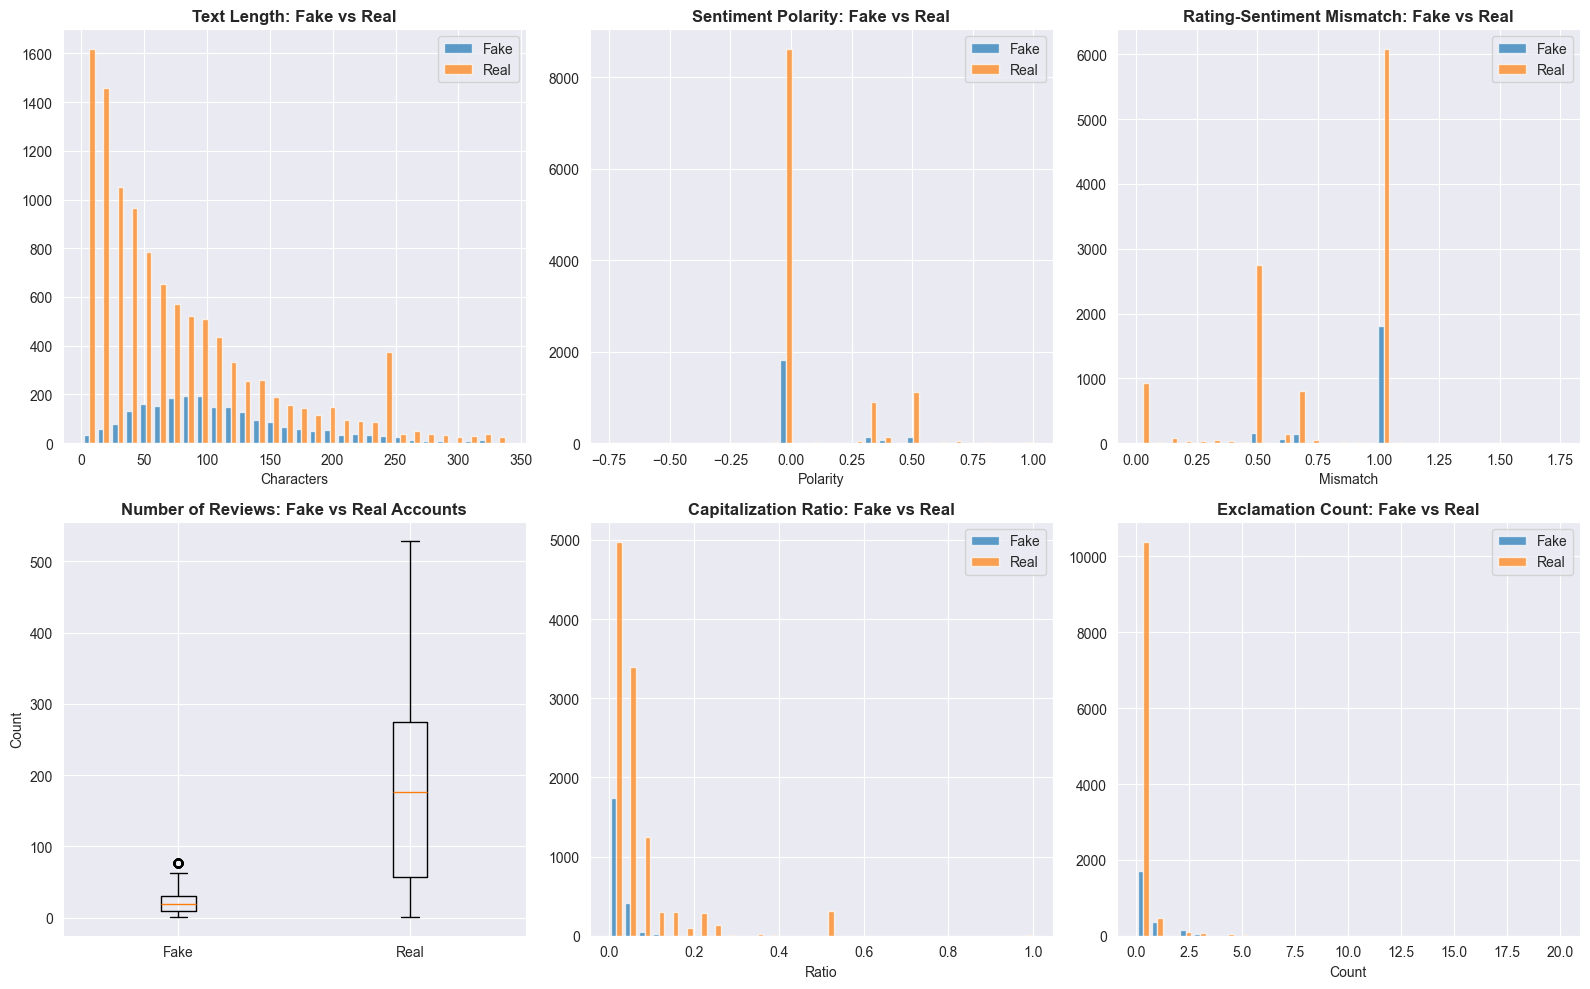


✅ Feature visualization saved!


In [ ]:
print("\n" + "=" * 80)
print("FEATURE VISUALIZATION")
print("=" * 80)

# Créer la figure
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Distribution longueur texte (faux vs réel)
fake_text = df[df['is_real'] == 0]['text_length']
real_text = df[df['is_real'] == 1]['text_length']
axes[0, 0].hist([fake_text, real_text], label=['Fake', 'Real'], bins=30, alpha=0.7)
axes[0, 0].set_title('Text Length: Fake vs Real', fontweight='bold')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].legend()

# Polarité sentiment (faux vs réel)
fake_sentiment = df[df['is_real'] == 0]['sentiment_polarity']
real_sentiment = df[df['is_real'] == 1]['sentiment_polarity']
axes[0, 1].hist([fake_sentiment, real_sentiment], label=['Fake', 'Real'], bins=30, alpha=0.7)
axes[0, 1].set_title('Sentiment Polarity: Fake vs Real', fontweight='bold')
axes[0, 1].set_xlabel('Polarity')
axes[0, 1].legend()

# Décalage Note-Sentiment (faux vs réel)
fake_mismatch = df[df['is_real'] == 0]['rating_sentiment_mismatch']
real_mismatch = df[df['is_real'] == 1]['rating_sentiment_mismatch']
axes[0, 2].hist([fake_mismatch, real_mismatch], label=['Fake', 'Real'], bins=30, alpha=0.7)
axes[0, 2].set_title('Rating-Sentiment Mismatch: Fake vs Real', fontweight='bold')
axes[0, 2].set_xlabel('Mismatch')
axes[0, 2].legend()

# Nombre d'avis par compte (faux vs réel)
fake_num = df[df['is_real'] == 0]['num_reviews']
real_num = df[df['is_real'] == 1]['num_reviews']
axes[1, 0].boxplot([fake_num, real_num], labels=['Fake', 'Real'])
axes[1, 0].set_title('Number of Reviews: Fake vs Real Accounts', fontweight='bold')
axes[1, 0].set_ylabel('Count')

# Ratio majuscules (faux vs réel)
fake_caps = df[df['is_real'] == 0]['caps_ratio']
real_caps = df[df['is_real'] == 1]['caps_ratio']
axes[1, 1].hist([fake_caps, real_caps], label=['Fake', 'Real'], bins=30, alpha=0.7)
axes[1, 1].set_title('Capitalization Ratio: Fake vs Real', fontweight='bold')
axes[1, 1].set_xlabel('Ratio')
axes[1, 1].legend()

# Nombre d'exclamations (faux vs réel)
fake_excl = df[df['is_real'] == 0]['exclamation_count']
real_excl = df[df['is_real'] == 1]['exclamation_count']
axes[1, 2].hist([fake_excl, real_excl], label=['Fake', 'Real'], bins=30, alpha=0.7)
axes[1, 2].set_title('Exclamation Count: Fake vs Real', fontweight='bold')
axes[1, 2].set_xlabel('Count')
axes[1, 2].legend()

plt.tight_layout()

# Créer le répertoire outputs s'il n'existe pas
from pathlib import Path
Path('../outputs').mkdir(exist_ok=True)

plt.savefig('../outputs/05_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Feature visualization saved!")

## Résumé des Caractéristiques

In [ ]:
print("\n" + "=" * 80)
print("FEATURES SUMMARY")
print("=" * 80)

# Lister toutes les caractéristiques
feature_cols = [col for col in df.columns if col not in [
    'review_id', 'account_id', 'review_text', 'is_real', 'rating_normalized',
    'account_id_orig', 'date', 'cluster', 'type_of_object', 'photos_urls',
    'response_content', 'censored_text', 'content_not_full', 'content_translated',
    'localization_missing', 'not_in_poland', 'is_deleted', 'is_private',
    'approximate_localization.lat', 'approximate_localization.lon'
]]

print(f"\n TOTAL CARACTÉRISTIQUES CRÉÉES : {len(feature_cols)}")

print(f"\n CARACTÉRISTIQUES PAR CATÉGORIE :")

text_features = ['text_length', 'word_count', 'sentence_count', 'exclamation_count', 
                 'question_count', 'caps_ratio', 'unique_words_ratio', 'avg_word_length', 'special_char_count']
print(f"\n  CARACTÉRISTIQUES TEXTUELLES ({len(text_features)}) :")
for feat in text_features:
    if feat in df.columns:
        print(f"    • {feat}")

sentiment_features = ['sentiment_polarity', 'sentiment_subjectivity', 'rating_sentiment_mismatch']
print(f"\n  CARACTÉRISTIQUES SENTIMENT ({len(sentiment_features)}) :")
for feat in sentiment_features:
    if feat in df.columns:
        print(f"    • {feat}")

behavior_features = ['num_reviews', 'avg_rating', 'rating_std', 'pct_positive', 'pct_negative']
print(f"\n  CARACTÉRISTIQUES COMPORTEMENT ({len(behavior_features)}) :")
for feat in behavior_features:
    if feat in df.columns:
        print(f"    • {feat}")

# Infos données
print(f"\n DATASET AFTER FEATURES:")
print(f"  Shape: {df.shape}")
print(f"  Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


FEATURES SUMMARY

✅ TOTAL FEATURES CREATED: 22

📋 FEATURES BY CATEGORY:

  TEXT FEATURES (9):
    • text_length
    • word_count
    • sentence_count
    • exclamation_count
    • question_count
    • caps_ratio
    • unique_words_ratio
    • avg_word_length
    • special_char_count

  SENTIMENT FEATURES (3):
    • sentiment_polarity
    • sentiment_subjectivity
    • rating_sentiment_mismatch

  BEHAVIOR FEATURES (5):
    • num_reviews
    • avg_rating
    • rating_std
    • pct_positive
    • pct_negative

📊 DATASET AFTER FEATURES:
  Shape: (13351, 42)
  Memory: 12.96 MB


## Statistiques des Caractéristiques

In [ ]:
print("\n" + "=" * 80)
print("FEATURES STATISTICS")
print("=" * 80)

# Sélectionner les caractéristiques numériques
numeric_features = df.select_dtypes(include=[np.number]).columns
numeric_df = df[numeric_features]

print(f"\n DESCRIPTION :")
display(numeric_df.describe())

# Corrélation avec le label
print(f"\n CORRÉLATION AVEC LE LABEL (is_real) :")
correlations = numeric_df.corr()['is_real'].sort_values(ascending=False)
print(correlations[1:11])  # Top 10 caractéristiques corrélées avec is_real


FEATURES STATISTICS

📊 DESCRIBE:


,approximate_localization.lat,approximate_localization.lon,is_real,rating,is_real_account,local_guide_level,name_score,number_of_reviews,text_length,word_count,...,avg_word_length,sentiment_polarity,sentiment_subjectivity,rating_normalized,rating_sentiment_mismatch,num_reviews,avg_rating,rating_std,pct_positive,pct_negative
count,13351.00000,13351.000000,13351.000000,13351.000000,13351.000000,13351.000000,1.335100e+04,13351.000000,13351.000000,13351.000000,...,13351.000000,13351.000000,13351.000000,13351.000000,13351.000000,13351.000000,13351.000000,13351.000000,13351.000000,13351.000000
mean,51.36622,17.289619,0.831473,4.578309,0.831473,5.164332,3.020598e+05,237.639128,81.676579,12.139390,...,5.854096,0.091391,0.143175,0.789154,0.773110,174.221482,4.578309,0.643522,0.903378,0.043368
std,3.79660,12.555309,0.374347,0.870657,0.374347,2.755362,2.674024e+05,225.574919,71.636709,10.820364,...,1.387320,0.188999,0.283616,0.435328,0.310988,169.721132,0.420091,0.430629,0.117706,0.073719
min,-37.80000,-158.100000,0.000000,1.000000,0.000000,0.000000,0.000000e+00,1.000000,1.000000,1.000000,...,1.000000,-0.750000,0.000000,-1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,50.50000,16.900000,1.000000,4.000000,1.000000,4.000000,6.339000e+03,44.000000,25.000000,4.000000,...,5.125000,0.000000,0.000000,0.500000,0.500000,34.000000,4.379310,0.441637,0.859649,0.000000
50%,51.90000,18.800000,1.000000,5.000000,1.000000,6.000000,2.630030e+05,169.000000,62.000000,9.000000,...,5.843750,0.000000,0.000000,1.000000,1.000000,106.000000,4.720930,0.613999,0.941176,0.018904
75%,53.00000,20.900000,1.000000,5.000000,1.000000,7.000000,4.799180e+05,338.000000,115.000000,17.000000,...,6.597297,0.000000,0.000000,1.000000,1.000000,254.000000,4.905242,0.948578,0.986175,0.051724
max,68.30000,150.800000,1.000000,5.000000,1.000000,8.000000,1.347560e+06,825.000000,338.000000,59.000000,...,19.000000,1.000000,1.000000,1.000000,1.750000,529.000000,5.000000,2.828427,1.000000,1.000000



📊 CORRELATION WITH LABEL (is_real):
is_real               1.000000
rating_std            0.598584
local_guide_level     0.481244
number_of_reviews     0.421772
num_reviews           0.401025
pct_negative          0.243141
caps_ratio            0.155916
name_score            0.137195
question_count        0.033244
unique_words_ratio    0.029786
Name: is_real, dtype: float64


## Sauvegarder les Caractéristiques

In [ ]:
from pathlib import Path

# Sauvegarder le jeu de données avec caractéristiques
output_path = Path('../data/processed/features_extracted.csv')
df.to_csv(output_path, index=False)

print(f"\n SAVED: {output_path}")
print(f"   Size: {output_path.stat().st_size / 1024**2:.2f} MB")

# Vérification
df_verify = pd.read_csv(output_path)
print(f"\n VÉRIFICATION :")
print(f"   Loaded shape : {df_verify.shape}")
print(f"   Prêt pour la modélisation !")


✅ SAVED: ..\data\processed\features_extracted.csv
   Size: 5.92 MB

✅ VERIFICATION:
   Loaded shape: (13351, 42)
   ✅ Ready for modeling!
